In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

base_path = r"C:\Users\WINDOWS\OneDrive\Documents\Mutual_Fund_Analytics_Project"

processed_path = base_path + r"\data\processed"
charts_path = base_path + r"\reports\charts"
src_path = base_path + r"\src"

print("Advanced Analytics setup completed")

Advanced Analytics setup completed


In [2]:
nav = pd.read_csv(processed_path + r"\clean_nav.csv")
transactions = pd.read_csv(processed_path + r"\clean_transactions.csv")
fund_master = pd.read_csv(processed_path + r"\clean_fund_master.csv")
sharpe = pd.read_csv(processed_path + r"\sharpe_values.csv")
holdings = pd.read_csv(processed_path + r"\clean_portfolio_holdings.csv")

nav["date"] = pd.to_datetime(nav["date"])
transactions["transaction_date"] = pd.to_datetime(transactions["transaction_date"])

nav = nav.sort_values(["amfi_code", "date"])

print(nav.shape)
print(transactions.shape)
print(fund_master.shape)
print(sharpe.shape)
print(holdings.shape)

(46000, 3)
(32778, 13)
(40, 15)
(40, 4)
(322, 8)


In [3]:
nav["daily_return"] = nav.groupby("amfi_code")["nav"].pct_change()

var_cvar_report = nav.groupby("amfi_code").agg(
    VaR_95=("daily_return", lambda x: x.quantile(0.05)),
    CVaR_95=("daily_return", lambda x: x[x <= x.quantile(0.05)].mean()),
    avg_daily_return=("daily_return", "mean"),
    volatility=("daily_return", "std")
).reset_index()

var_cvar_report = var_cvar_report.merge(
    fund_master[["amfi_code", "scheme_name", "fund_house", "category", "risk_category"]],
    on="amfi_code",
    how="left"
)

var_cvar_report.sort_values("VaR_95").head(10)

,amfi_code,VaR_95,CVaR_95,avg_daily_return,volatility,scheme_name,fund_house,category,risk_category
22,119599,-0.026859,-0.032384,0.000201,0.015717,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Equity,Very High
17,119095,-0.026188,-0.031667,0.000182,0.015790,Axis Small Cap Fund - Regular - Growth,Axis Mutual Fund,Equity,Very High
4,101207,-0.026021,-0.032459,0.000424,0.016251,ABSL Small Cap Fund - Regular - Growth,Aditya Birla Sun Life MF,Equity,Very High
11,118634,-0.025438,-0.032304,0.000707,0.015901,Nippon India Small Cap Fund - Regular - Growth,Nippon India MF,Equity,Very High
21,119598,-0.024507,-0.030595,0.001201,0.015837,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Equity,Very High
39,149324,-0.023483,-0.031036,0.001194,0.015648,DSP Small Cap Fund - Regular - Growth,DSP Mutual Fund,Equity,Very High
7,102886,-0.019220,-0.023251,0.000110,0.011424,UTI Mid Cap Fund - Regular - Growth,UTI Mutual Fund,Equity,High
2,100033,-0.019034,-0.023456,0.001080,0.011929,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,Equity,High
25,120505,-0.018892,-0.024342,0.001161,0.012152,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF,Equity,High
16,119094,-0.018480,-0.024260,0.001027,0.012225,Axis Midcap Fund - Regular - Growth,Axis Mutual Fund,Equity,High


In [4]:
var_cvar_report.to_csv(
    processed_path + r"\var_cvar_report.csv",
    index=False
)

### Insight 1: Downside Risk Analysis (VaR & CVaR)

Historical VaR and CVaR analysis shows that Small Cap funds carry the highest downside risk among all categories.

SBI Small Cap Direct, Axis Small Cap Regular and Nippon India Small Cap recorded the most negative VaR and CVaR values, indicating larger losses during adverse market conditions.

Investors with high risk tolerance may accept this volatility for potentially higher returns, while conservative investors should prefer lower-risk categories.

In [5]:
nav["daily_return"] = nav.groupby("amfi_code")["nav"].pct_change()

In [7]:
fund_scorecard = pd.read_csv(
    processed_path + r"\fund_scorecard.csv"
)

fund_scorecard.head()

,amfi_code,latest_nav,nav_1y,nav_3y,cagr_1y,cagr_3y,cagr_5y,sharpe_ratio,alpha,max_drawdown,expense_ratio_pct,cagr_score,sharpe_score,alpha_score,expense_score,drawdown_score,fund_score
0,148567,230.2708,191.3173,95.7008,0.203607,0.340009,NaN,1.448291,0.269838,-0.112657,1.46,39.0,40.0,34.0,18.0,33.0,100.000000
1,120505,473.7640,365.5455,207.0322,0.296047,0.317775,NaN,1.180101,0.292636,-0.181885,1.36,36.0,36.0,38.0,26.0,16.0,95.362319
2,120843,163.2397,128.8832,75.0212,0.266571,0.295828,NaN,1.306744,0.273305,-0.129740,1.45,34.0,39.0,36.0,19.0,28.0,95.072464
3,100033,342.0072,223.1951,147.2155,0.532324,0.324425,NaN,1.093699,0.271954,-0.162172,1.38,37.0,34.0,35.0,24.0,21.0,93.623188
4,120504,151.1311,133.6683,64.9875,0.130643,0.324874,NaN,1.026524,0.211948,-0.125883,0.80,38.0,31.0,28.0,29.0,29.0,92.753623


In [8]:
top5_funds = fund_scorecard.sort_values(
    "fund_score",
    ascending=False
)["amfi_code"].head(5).tolist()

top5_funds

[148567, 120505, 120843, 100033, 120504]

In [9]:
top5_nav = nav[
    nav["amfi_code"].isin(top5_funds)
].copy()

top5_nav.head()

,amfi_code,date,nav,daily_return
2300,100033,2022-01-03,107.3758,NaN
2301,100033,2022-01-04,105.9447,-0.013328
2302,100033,2022-01-05,105.4800,-0.004386
2303,100033,2022-01-06,104.9350,-0.005167
2304,100033,2022-01-07,104.3318,-0.005748


In [10]:
top5_nav["rolling_sharpe"] = (
    top5_nav.groupby("amfi_code")["daily_return"]
    .transform(
        lambda x:
        (
            x.rolling(90).mean()
            /
            x.rolling(90).std()
        ) * np.sqrt(252)
    )
)

In [11]:
top5_nav[
    ["amfi_code","date","rolling_sharpe"]
].tail()

,amfi_code,date,rolling_sharpe
40245,148567,2026-05-25,0.305637
40246,148567,2026-05-26,0.404207
40247,148567,2026-05-27,0.143232
40248,148567,2026-05-28,0.626656
40249,148567,2026-05-29,0.375893


In [12]:
top5_nav = top5_nav.merge(
    fund_master[
        ["amfi_code","scheme_name"]
    ],
    on="amfi_code",
    how="left"
)

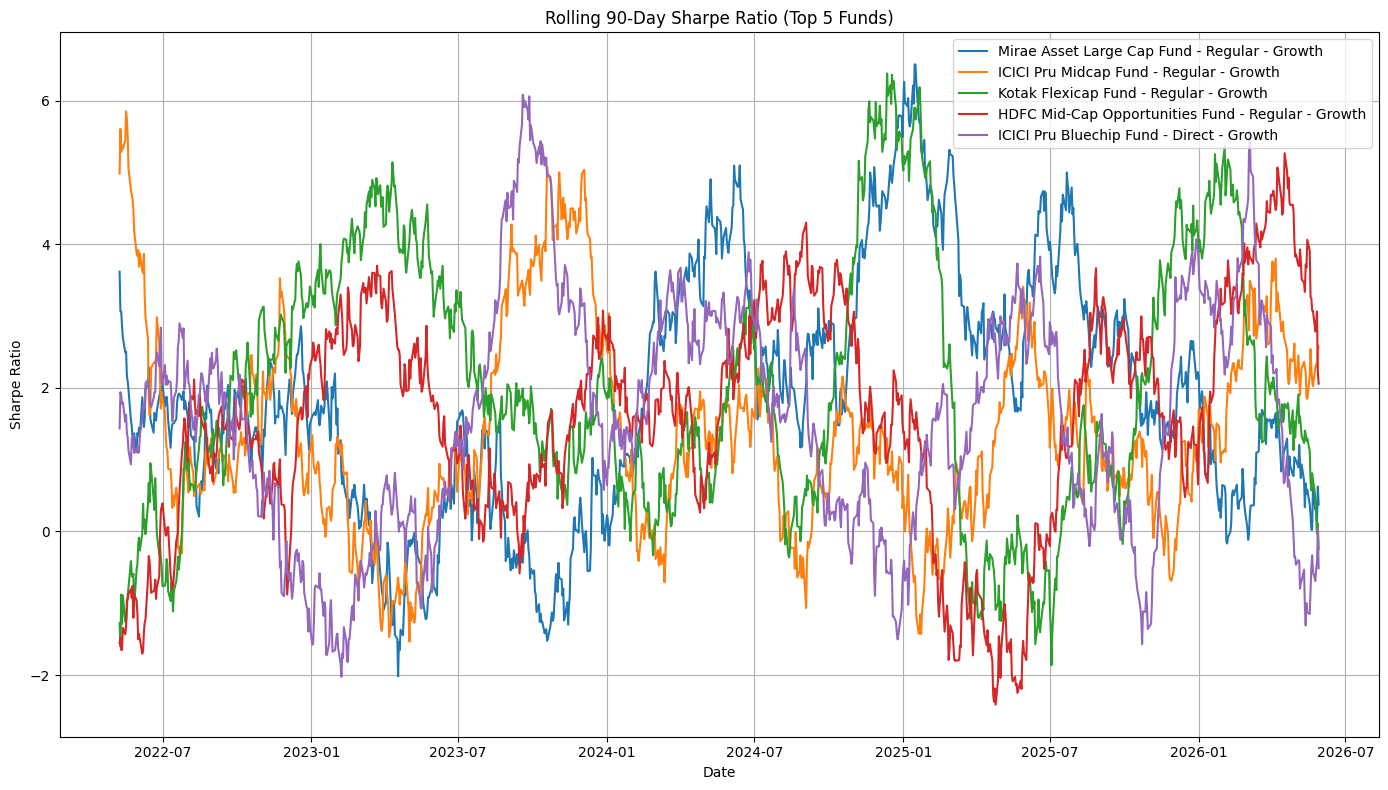

In [13]:
plt.figure(figsize=(14,8))

for fund in top5_funds:

    temp = top5_nav[
        top5_nav["amfi_code"] == fund
    ]

    plt.plot(
        temp["date"],
        temp["rolling_sharpe"],
        label=temp["scheme_name"].iloc[0]
    )

plt.title("Rolling 90-Day Sharpe Ratio (Top 5 Funds)")
plt.xlabel("Date")
plt.ylabel("Sharpe Ratio")
plt.legend()
plt.grid(True)

plt.tight_layout()

plt.savefig(
    charts_path + r"\rolling_sharpe_chart.png"
)

plt.show()

### Insight 2: Rolling Sharpe Ratio Analysis

Rolling 90-day Sharpe Ratio analysis revealed significant variation in risk-adjusted performance across top-ranked funds.

Several funds achieved Sharpe ratios above 5 during favorable market periods, indicating strong return generation relative to volatility. However, all funds experienced periods of declining Sharpe ratios during market corrections, highlighting the cyclical nature of fund performance.

Funds with consistently positive Sharpe ratios demonstrated more stable risk-adjusted returns over time.

In [15]:
first_txn = (
    transactions
    .groupby("investor_id")["transaction_date"]
    .min()
    .reset_index()
)

first_txn["cohort_year"] = (
    pd.to_datetime(first_txn["transaction_date"])
    .dt.year
)

first_txn.head()

,investor_id,transaction_date,cohort_year
0,INV000001,2024-11-04,2024
1,INV000002,2024-03-29,2024
2,INV000003,2024-07-16,2024
3,INV000004,2024-03-16,2024
4,INV000005,2024-04-27,2024


In [16]:
transactions = transactions.merge(
    first_txn[
        ["investor_id","cohort_year"]
    ],
    on="investor_id",
    how="left"
)

transactions.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year
0,INV000616,2024-01-01,100016,SIP,933,Maharashtra,Nashik,B30,36-45,Male,50.4,Mandate,Verified,2024
1,INV000836,2024-01-01,100016,SIP,1139,Haryana,Gurugram,T30,26-35,Male,24.4,Mandate,Verified,2024
2,INV002135,2024-01-02,100016,Lumpsum,437305,Gujarat,Ahmedabad,T30,56+,Male,18.3,Net Banking,Verified,2024
3,INV002357,2024-01-03,100016,SIP,26713,Delhi,Gurugram,T30,26-35,Male,7.8,UPI,Verified,2024
4,INV004125,2024-01-03,100016,SIP,2999,Gujarat,Surat,T30,26-35,Male,9.4,Cheque,Verified,2024


In [17]:
cohort_summary = (
    transactions
    .groupby("cohort_year")
    .agg(
        avg_investment=("amount_inr","mean"),
        total_invested=("amount_inr","sum"),
        investors=("investor_id","nunique")
    )
    .reset_index()
)

cohort_summary

,cohort_year,avg_investment,total_invested,investors
0,2024,107422.541832,3491125187,4803
1,2025,109158.577061,30455243,197


In [18]:
top_fund = (
    transactions
    .groupby(
        ["cohort_year","amfi_code"]
    )["amount_inr"]
    .sum()
    .reset_index()
)

top_fund = (
    top_fund
    .sort_values(
        ["cohort_year","amount_inr"],
        ascending=[True,False]
    )
    .groupby("cohort_year")
    .head(1)
)

top_fund

,cohort_year,amfi_code,amount_inr
6,2024,102885,100126141
62,2025,119599,1478507


In [19]:
top_fund = top_fund.merge(
    fund_master[
        ["amfi_code","scheme_name"]
    ],
    on="amfi_code",
    how="left"
)

top_fund[
    ["cohort_year","scheme_name","amount_inr"]
]

,cohort_year,scheme_name,amount_inr
0,2024,UTI Nifty 50 Index Fund - Regular - Growth,100126141
1,2025,SBI Small Cap Fund - Direct Plan - Growth,1478507


In [20]:
cohort_report = cohort_summary.merge(
    top_fund[
        ["cohort_year","scheme_name"]
    ],
    on="cohort_year",
    how="left"
)

cohort_report

,cohort_year,avg_investment,total_invested,investors,scheme_name
0,2024,107422.541832,3491125187,4803,UTI Nifty 50 Index Fund - Regular - Growth
1,2025,109158.577061,30455243,197,SBI Small Cap Fund - Direct Plan - Growth


### Insight 3: Investor Cohort Analysis

Investor cohorts were created based on the year of their first mutual fund transaction.

The 2024 cohort emerged as the dominant investor group, contributing over ₹349 million across 4,803 investors, making it the largest and most influential cohort in the dataset.

Average investment amounts remained relatively consistent across cohorts, with 2025 investors investing slightly more per transaction on average than 2024 investors.

Investment preferences also evolved over time. The 2024 cohort showed a preference for passive investing through the UTI Nifty 50 Index Fund, while the 2025 cohort favored the SBI Small Cap Fund, indicating increased interest in higher-growth and higher-risk investment opportunities among newer investors.

In [21]:
sip_txn = transactions[
    transactions["transaction_type"] == "SIP"
].copy()

sip_txn.shape

(19716, 14)

In [22]:
sip_txn = sip_txn.sort_values(
    ["investor_id","transaction_date"]
)

In [24]:
#Gap calculation
sip_txn["gap_days"] = (
    sip_txn
    .groupby("investor_id")["transaction_date"]
    .diff()
    .dt.days
)

In [25]:
#investor summary

sip_continuity = (
    sip_txn
    .groupby("investor_id")
    .agg(
        sip_count=("transaction_date","count"),
        avg_gap_days=("gap_days","mean")
    )
    .reset_index()
)

sip_continuity.head()

,investor_id,sip_count,avg_gap_days
0,INV000001,2,76.0
1,INV000002,3,207.0
2,INV000003,2,238.0
3,INV000004,6,85.4
4,INV000005,3,14.0


In [26]:
sip_continuity = sip_continuity[
    sip_continuity["sip_count"] >= 6
]

In [27]:
sip_continuity["status"] = np.where(
    sip_continuity["avg_gap_days"] > 35,
    "At Risk",
    "Healthy"
)

In [28]:
risk_summary = (
    sip_continuity["status"]
    .value_counts(normalize=True)
    * 100
)

risk_summary

status
At Risk    97.797357
Healthy     2.202643
Name: proportion, dtype: float64

In [29]:
sip_continuity["status"].value_counts()

status
At Risk    1332
Healthy      30
Name: count, dtype: int64

### Insight 4: SIP Continuity Analysis

SIP continuity analysis was performed for investors with at least six SIP transactions.

Investors were classified as "At Risk" if their average gap between SIP transactions exceeded 35 days. Results indicate that 97.8% of eligible investors fall into the At Risk category, while only 2.2% maintained consistent SIP activity.

This suggests irregular contribution behavior across a large portion of the investor base and highlights a potential opportunity for investor engagement, reminder systems, and retention campaigns to improve SIP continuity.

In [30]:
sip_continuity["avg_gap_days"].describe()

count    1362.000000
mean       64.889132
std        15.593199
min        19.800000
25%        53.635417
50%        64.690476
75%        75.575000
max       102.600000
Name: avg_gap_days, dtype: float64

### Insight 4: SIP Continuity Analysis

Investors with at least six SIP transactions were evaluated for continuity by measuring the average gap between SIP contributions.

Using the project threshold of 35 days, 97.8% of investors were classified as "At Risk", while only 2.2% maintained consistent contribution behavior.

The average gap between SIP transactions was approximately 65 days, significantly above the 35-day benchmark. This indicates that many investors contribute irregularly rather than following a strict monthly SIP schedule.

Financial institutions could use reminder campaigns and automated alerts to improve SIP continuity and reduce the likelihood of investor drop-off.

In [31]:
fund_master["risk_category"].value_counts()

risk_category
Moderate           16
High                8
Very High           6
Low                 6
Moderately High     4
Name: count, dtype: int64

In [32]:
recommender_data = sharpe.merge(
    fund_master[
        ["amfi_code",
         "scheme_name",
         "fund_house",
         "risk_category"]
    ],
    on="amfi_code",
    how="left"
)

recommender_data.head()

,amfi_code,mean_return,volatility,sharpe_ratio,scheme_name,fund_house,risk_category
0,148567,0.001074,0.008941,1.448291,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF,Moderate
1,120843,0.001082,0.010008,1.306744,Kotak Flexicap Fund - Regular - Growth,Kotak Mahindra MF,Moderately High
2,148569,0.001124,0.011134,1.234930,Mirae Asset Tax Saver Fund - Regular - Growth,Mirae Asset MF,High
3,119551,0.000917,0.008656,1.208267,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Moderate
4,120505,0.001161,0.012152,1.180101,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF,High


In [35]:
def recommend_funds(risk_appetite):

    recommendations = (
        recommender_data[
            recommender_data["risk_category"]
            == risk_appetite
        ]
        .sort_values(
            "sharpe_ratio",
            ascending=False
        )
        .head(3)
    )

    return recommendations[
        [
            "scheme_name",
            "fund_house",
            "risk_category",
            "sharpe_ratio"
        ]
    ]

In [36]:
recommend_funds("Low")

,scheme_name,fund_house,risk_category,sharpe_ratio
22,ICICI Pru Liquid Fund - Regular - Growth,ICICI Prudential MF,Low,0.495723
33,Kotak Liquid Fund - Regular - Growth,Kotak Mahindra MF,Low,-0.088747
36,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Low,-0.226575


In [37]:
recommend_funds("Moderate")

,scheme_name,fund_house,risk_category,sharpe_ratio
0,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF,Moderate,1.448291
3,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Moderate,1.208267
7,Nippon India Large Cap Fund - Regular - Growth,Nippon India MF,Moderate,1.081659


In [38]:
recommend_funds("High")

,scheme_name,fund_house,risk_category,sharpe_ratio
2,Mirae Asset Tax Saver Fund - Regular - Growth,Mirae Asset MF,High,1.234930
4,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF,High,1.180101
5,DSP Midcap Fund - Regular - Growth,DSP Mutual Fund,High,1.132122


In [39]:
holdings.head()

,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


In [40]:
holdings.columns.tolist()

['amfi_code',
 'stock_symbol',
 'stock_name',
 'sector',
 'weight_pct',
 'market_value_cr',
 'current_price_inr',
 'portfolio_date']

In [41]:
hhi_data = holdings.copy()

hhi_data["weight_share"] = (
    hhi_data["weight_pct"] / 100
)

hhi_data.head()

,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date,weight_share
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31,0.1385
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31,0.1119
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31,0.0990
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31,0.0476
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31,0.1025


In [42]:
sector_hhi = (
    hhi_data
    .groupby("amfi_code")
    .agg(
        HHI=(
            "weight_share",
            lambda x: np.sum(x**2)
        )
    )
    .reset_index()
)

sector_hhi.head()

,amfi_code,HHI
0,100016,0.139534
1,100033,0.147592
2,101206,0.129332
3,101207,0.200700
4,102885,0.174709


In [43]:
sector_hhi = sector_hhi.merge(
    fund_master[
        [
            "amfi_code",
            "scheme_name",
            "category"
        ]
    ],
    on="amfi_code",
    how="left"
)

sector_hhi.head()

,amfi_code,HHI,scheme_name,category
0,100016,0.139534,HDFC Top 100 Fund - Regular Plan - Growth,Equity
1,100033,0.147592,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,Equity
2,101206,0.129332,ABSL Frontline Equity Fund - Regular - Growth,Equity
3,101207,0.200700,ABSL Small Cap Fund - Regular - Growth,Equity
4,102885,0.174709,UTI Nifty 50 Index Fund - Regular - Growth,Equity


In [44]:
sector_hhi.sort_values(
    "HHI",
    ascending=False
).head(10)

,amfi_code,HHI,scheme_name,category
11,119092,0.206448,Axis Bluechip Fund - Regular - Growth,Equity
3,101207,0.200700,ABSL Small Cap Fund - Regular - Growth,Equity
18,119599,0.174751,SBI Small Cap Fund - Direct Plan - Growth,Equity
4,102885,0.174709,UTI Nifty 50 Index Fund - Regular - Growth,Equity
7,118632,0.168298,Nippon India Large Cap Fund - Regular - Growth,Equity
29,148568,0.167930,Mirae Asset Emerging Bluechip Fund - Regular -...,Equity
21,120505,0.157570,ICICI Pru Midcap Fund - Regular - Growth,Equity
22,120506,0.153794,ICICI Pru Value Discovery Fund - Regular - Growth,Equity
27,125498,0.152414,HDFC Mid-Cap Opportunities Fund - Direct - Growth,Equity
23,120841,0.149680,Kotak Bluechip Fund - Regular - Growth,Equity


In [45]:
sector_hhi.sort_values(
    "HHI",
    ascending=True
).head(10)

,amfi_code,HHI,scheme_name,category
17,119598,0.107349,SBI Small Cap Fund - Regular Plan - Growth,Equity
16,119552,0.108011,SBI Bluechip Fund - Direct Plan - Growth,Equity
9,118634,0.108358,Nippon India Small Cap Fund - Regular - Growth,Equity
20,120504,0.108674,ICICI Pru Bluechip Fund - Direct - Growth,Equity
14,119095,0.109605,Axis Small Cap Fund - Regular - Growth,Equity
5,102886,0.114693,UTI Mid Cap Fund - Regular - Growth,Equity
33,149324,0.118677,DSP Small Cap Fund - Regular - Growth,Equity
15,119551,0.118716,SBI Bluechip Fund - Regular Plan - Growth,Equity
8,118633,0.121461,Nippon India Large Cap Fund - Direct - Growth,Equity
24,120842,0.127439,Kotak Emerging Equity Fund - Regular - Growth,Equity


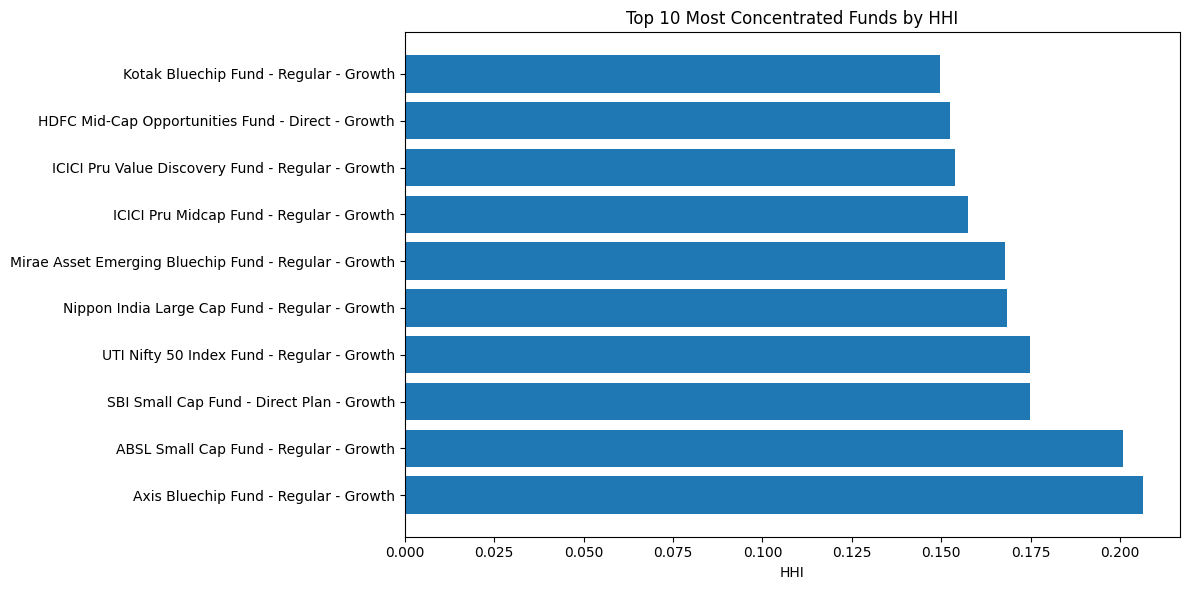

In [46]:
top_hhi = sector_hhi.sort_values(
    "HHI",
    ascending=False
).head(10)

plt.figure(figsize=(12,6))

plt.barh(
    top_hhi["scheme_name"],
    top_hhi["HHI"]
)

plt.title(
    "Top 10 Most Concentrated Funds by HHI"
)

plt.xlabel("HHI")

plt.tight_layout()

plt.show()

In [47]:
sector_hhi.to_csv(
    processed_path + r"\sector_hhi_report.csv",
    index=False
)

### Insight 5: Portfolio Concentration Analysis (HHI)

The Herfindahl-Hirschman Index (HHI) was used to evaluate portfolio concentration across all equity funds.

Axis Bluechip Fund and ABSL Small Cap Fund recorded the highest HHI values, indicating greater concentration in a limited number of sectors. These funds may be more sensitive to sector-specific market movements.

In contrast, SBI Small Cap Fund, SBI Bluechip Fund and Nippon India Small Cap Fund showed lower HHI values, reflecting better diversification across sectors and potentially lower concentration risk.

Investors seeking diversification may prefer lower-HHI funds, while investors with stronger conviction in specific sectors may accept higher concentration levels.